In [1]:
from ultralytics import YOLO
import cv2

In [2]:
import numpy as np


In [6]:
cap = cv2.VideoCapture(0)

In [16]:
cap = cv2.VideoCapture(0)
while True:
    
    ret, frame = cap.read()
    
    if not ret:
        break
    
    # print(frame)
    frame = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    cv2.imshow("video",frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::disableSurface(wl_surface*) Trying to disable 0x601c8db2d300 but 0x0 is focused
qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::disableSurface(wl_surface*) Trying to disable 0x601c8db2d300 but 0x0 is focused
qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::disableSurface(wl_surface*) Trying to disable 0x601c8db2d300 but 0x0 is focused


In [1]:
import cv2

In [4]:
face_cascade = cv2.CascadeClassifier(
    "haarcascade_frontalface_default.xml"
)

In [ ]:
cap = cv2.VideoCapture(0)

while True:
    
    ret, frame = cap.read()
    
    if not ret:
        
        break
    
    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50,50)
    )
    
    for (x,y,w,h) in faces:
        cv2.rectangle(
            frame,
            (x,y),
            (x+w, y+h),
            (0,255,0),
            2
        )
        
        face = gray[y:y+h,x:x+w]
        
        face_blur = cv2.GaussianBlur(
            face,
            (5,5),
            0
        )
        
        edges = cv2.Canny(
            face_blur,
            50,
            150
        )
        cv2.imshow("Face edges",edges)
    
    cv2.imshow("face detection",frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [1]:
import mediapipe as mp


In [7]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

image = cv2.imread("profile.jpeg")
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


mp_face_mesh = mp.solutions.face_mesh


cv2.imshow("Image", rgb)
cv2.waitKey(0)
cv2.destroyAllWindows()


AttributeError: module 'mediapipe' has no attribute 'solutions'

In [8]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("MediaPipe location:", mp.__file__)
print("Has solutions:", hasattr(mp, "solutions"))
print("Has tasks:", hasattr(mp, "tasks"))

MediaPipe version: 1.1.0
MediaPipe location: /home/sumanth/miniconda3/envs/ultralytics-env/lib/python3.11/site-packages/mediapipe/__init__.py
Has solutions: False
Has tasks: True


In [9]:
import cv2
import mediapipe as mp

model_path = "/home/sumanth/Downloads/face_landmarker.task"

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=model_path
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1
)

image = mp.Image.create_from_file("profile.jpeg")

with FaceLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(image)

print("Faces detected:", len(result.face_landmarks))

W0000 00:00:1791367978.728011  511424 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1791367978.751088  511434 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791367978.768224  511434 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Faces detected: 1


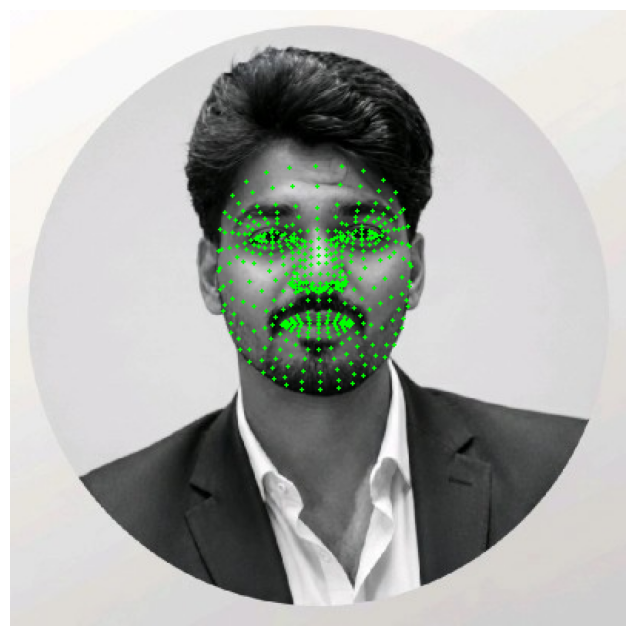

In [10]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("profile.jpeg")

h, w, _ = image.shape

for landmark in result.face_landmarks[0]:

    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.circle(
        image,
        (x, y),
        1,
        (0, 255, 0),
        -1
    )

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [11]:
landmarks = result.face_landmarks[0]

print("Number of landmarks:", len(landmarks))

print("\nFirst landmark:")
print("x =", landmarks[0].x)
print("y =", landmarks[0].y)
print("z =", landmarks[0].z)

Number of landmarks: 478

First landmark:
x = 0.5009381175041199
y = 0.4930996894836426
z = -0.041204407811164856


In [12]:
landmarks = result.face_landmarks[0]

print("Total landmarks:", len(landmarks))

for i in range(10):
    print(
        i,
        "x:", landmarks[i].x,
        "y:", landmarks[i].y,
        "z:", landmarks[i].z
    )

Total landmarks: 478
0 x: 0.5009381175041199 y: 0.4930996894836426 z: -0.041204407811164856
1 x: 0.5026856660842896 y: 0.44306761026382446 z: -0.07535108178853989
2 x: 0.5018056631088257 y: 0.4597507119178772 z: -0.04073639586567879
3 x: 0.4899080991744995 y: 0.40024280548095703 z: -0.05541185662150383
4 x: 0.5026168823242188 y: 0.4285494089126587 z: -0.07955697178840637
5 x: 0.5020632743835449 y: 0.4112682342529297 z: -0.07338381558656693
6 x: 0.500585675239563 y: 0.371207594871521 z: -0.03426549956202507
7 x: 0.40394067764282227 y: 0.3744199573993683 z: 0.0184694305062294
8 x: 0.499123752117157 y: 0.3388724625110626 z: -0.023779986426234245
9 x: 0.49870240688323975 y: 0.3200984001159668 z: -0.025874974206089973


In [13]:
h, w, _ = image.shape

points = []

for landmark in landmarks:
    x = int(landmark.x * w)
    y = int(landmark.y * h)

    points.append((x, y))

print("First 10 pixel coordinates:")
print(points[:10])

First 10 pixel coordinates:
[(200, 197), (201, 177), (200, 183), (195, 160), (201, 171), (200, 164), (200, 148), (161, 149), (199, 135), (199, 128)]


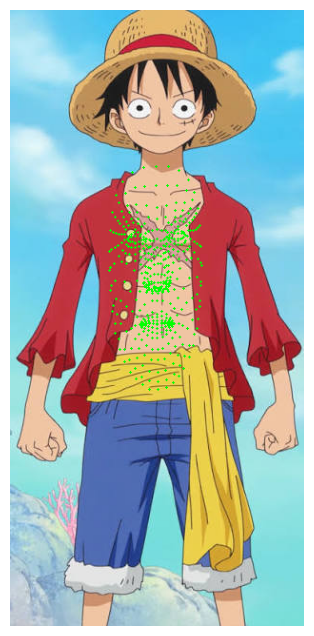

In [15]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp

image = cv2.imread("images.jpeg")

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mp_face_mesh = mp.tasks.vision.FaceLandmarker

# We already have `result`
landmarks = result.face_landmarks[0]

h, w, _ = image.shape

points = []

for landmark in landmarks:
    x = int(landmark.x * w)
    y = int(landmark.y * h)
    points.append((x, y))

# Draw points
for x, y in points:
    cv2.circle(image, (x, y), 1, (0, 255, 0), -1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [16]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 2.9 MB/s  0:00:12a 0:00:01m eta 0:00:01m


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

image = cv2.imread("profile.jpeg")

h, w, _ = image.shape

# Get landmark points from MediaPipe result
landmarks = result.face_landmarks[0]

points = np.array([
    [int(lm.x * w), int(lm.y * h)]
    for lm in landmarks
])

print("Points:", points.shape)

Points: (478, 2)


In [19]:
tri = Delaunay(points)

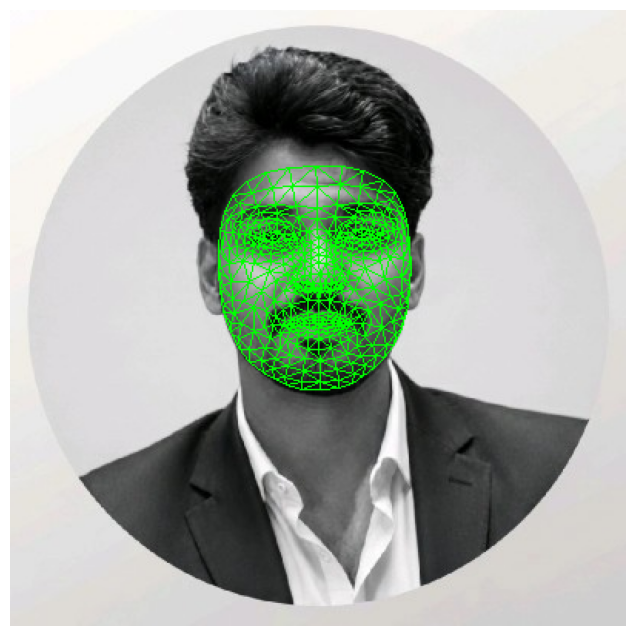

In [20]:
mesh_image = image.copy()

for triangle in tri.simplices:

    pts = points[triangle]

    cv2.polylines(
        mesh_image,
        [pts.astype(np.int32)],
        True,
        (0, 255, 0),
        1
    )

plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(mesh_image, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

In [21]:
import cv2
import mediapipe as mp
import numpy as np

model_path = "/home/sumanth/Downloads/face_landmarker.task"

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1
)

def get_landmarks(image_path):

    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(image_path)

    h, w = image.shape[:2]

    mp_image = mp.Image.create_from_file(image_path)

    with FaceLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    if len(result.face_landmarks) == 0:
        raise ValueError(f"No face found in {image_path}")

    landmarks = result.face_landmarks[0]

    points = np.array([
        [int(lm.x * w), int(lm.y * h)]
        for lm in landmarks
    ], dtype=np.float32)

    return image, points

In [72]:
source_img, source_points = get_landmarks("profile1.jpeg")
target_img, target_points = get_landmarks("profile2.jpeg")

print("Source:", source_points.shape)
print("Target:", target_points.shape)

W0000 00:00:1791370201.800038  530040 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1791370201.936455  530042 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791370202.032713  530043 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791370202.731812  530047 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1791370202.735646  530050 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791370202.865669  530049 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Source: (478, 2)
Target: (478, 2)


In [73]:
from scipy.spatial import Delaunay

tri = Delaunay(source_points)

triangle_indices = tri.simplices[0]

print(triangle_indices)

[ 50 123 117]


In [74]:
src_triangle = source_points[triangle_indices]
dst_triangle = target_points[triangle_indices]

print("Source triangle:")
print(src_triangle)

print("\nTarget triangle:")
print(dst_triangle)

Source triangle:
[[166. 172.]
 [157. 171.]
 [164. 162.]]

Target triangle:
[[225. 141.]
 [204. 135.]
 [223. 124.]]


In [75]:
matrix = cv2.getAffineTransform(
    src_triangle.astype(np.float32),
    dst_triangle.astype(np.float32)
)

print(matrix)

[[   2.36363636   -0.27272727 -120.45454545]
 [   0.48863636    1.60227273 -215.70454545]]


In [76]:
warped = cv2.warpAffine(
    source_img,
    matrix,
    (target_img.shape[1], target_img.shape[0])
)

In [77]:
mask = np.zeros(
    target_img.shape[:2],
    dtype=np.uint8
)

cv2.fillConvexPoly(
    mask,
    dst_triangle.astype(np.int32),
    255
)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(335, 596), dtype=uint8)

In [78]:
triangle_result = cv2.bitwise_and(
    warped,
    warped,
    mask=mask
)

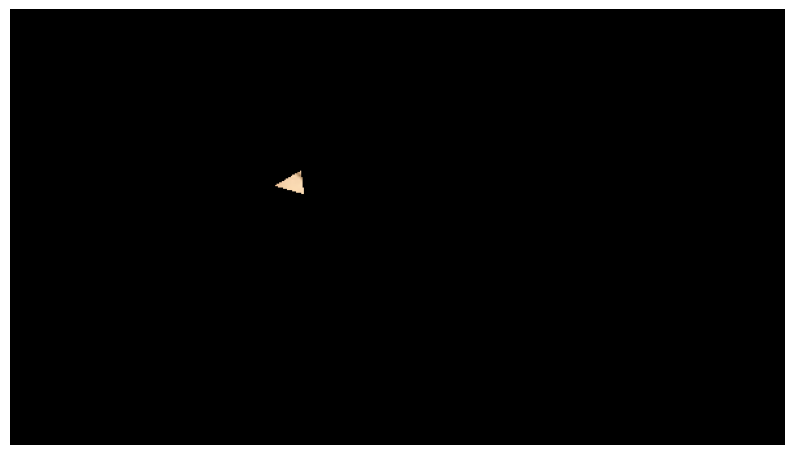

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(triangle_result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

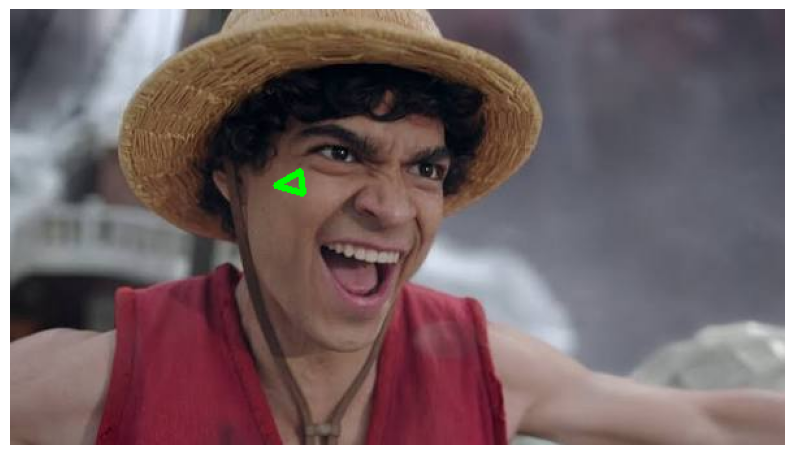

Triangle indices: [ 50 123 117]
Triangle points:
 [[225. 141.]
 [204. 135.]
 [223. 124.]]


In [80]:
import matplotlib.pyplot as plt
import cv2

# Show target image + selected triangle
debug = target_img.copy()

triangle_indices = tri.simplices[0]
triangle = target_points[triangle_indices]

cv2.polylines(
    debug,
    [triangle.astype(np.int32)],
    isClosed=True,
    color=(0, 255, 0),
    thickness=3
)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("Triangle indices:", triangle_indices)
print("Triangle points:\n", triangle)

In [81]:
triangle_indices = tri.simplices[0]

In [82]:
mask = np.zeros(target_img.shape[:2], dtype=np.uint8)

cv2.fillConvexPoly(
    mask,
    dst_triangle.astype(np.int32),
    255
)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(335, 596), dtype=uint8)

In [83]:
triangle_result = cv2.bitwise_and(
    warped,
    warped,
    mask=mask
)

In [84]:
tri.simplices[0]

array([ 50, 123, 117], dtype=int32)

In [85]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create empty image same size as target
warped_face = np.zeros_like(target_img)

# Delaunay triangulation on source landmarks
tri = Delaunay(source_points)

for triangle_indices in tri.simplices:

    # Source triangle
    src_tri = source_points[triangle_indices].astype(np.float32)

    # Target triangle
    dst_tri = target_points[triangle_indices].astype(np.float32)

    # Bounding rectangles
    src_rect = cv2.boundingRect(src_tri)
    dst_rect = cv2.boundingRect(dst_tri)

    sx, sy, sw, sh = src_rect
    dx, dy, dw, dh = dst_rect

    # Avoid invalid rectangles
    if sw <= 0 or sh <= 0 or dw <= 0 or dh <= 0:
        continue

    # Shift triangle coordinates relative to bounding rectangles
    src_tri_rect = src_tri - np.array([sx, sy], dtype=np.float32)
    dst_tri_rect = dst_tri - np.array([dx, dy], dtype=np.float32)

    # Crop source triangle region
    src_crop = source_img[sy:sy+sh, sx:sx+sw]

    # Affine transformation
    matrix = cv2.getAffineTransform(
        src_tri_rect,
        dst_tri_rect
    )

    # Warp only this triangle region
    warped = cv2.warpAffine(
        src_crop,
        matrix,
        (dw, dh),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    # Triangle mask
    mask = np.zeros((dh, dw), dtype=np.uint8)

    cv2.fillConvexPoly(
        mask,
        dst_tri_rect.astype(np.int32),
        255
    )

    # Destination region
    dst_region = warped_face[dy:dy+dh, dx:dx+dw]

    # Composite triangle
    dst_region[mask == 255] = warped[mask == 255]

    # Put back
    warped_face[dy:dy+dh, dx:dx+dw] = dst_region

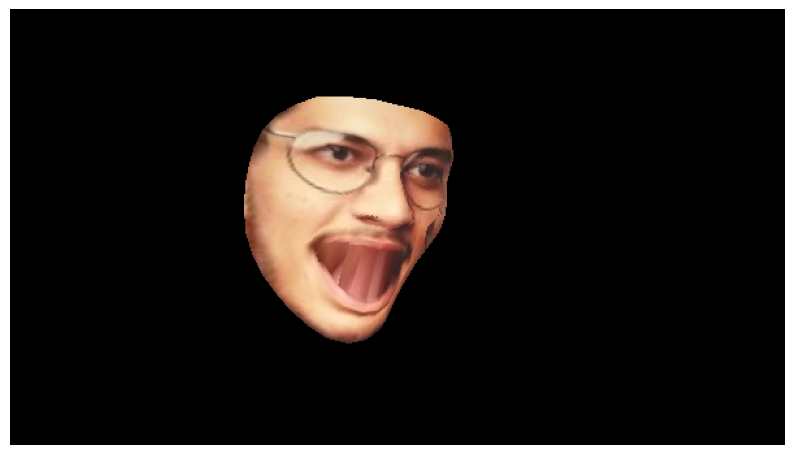

In [86]:
plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(warped_face, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

In [ ]:
# cv2.seamlessClone()

error: OpenCV(5.0.0) :-1: error: (-5:Bad argument) in function 'seamlessClone'
> Overload resolution failed:
>  - seamlessClone() missing required argument 'src' (pos 1)
>  - seamlessClone() missing required argument 'src' (pos 1)


In [87]:
# Convert landmarks to integer coordinates
target_points_int = target_points.astype(np.int32)

# Find convex hull around target face landmarks
hull = cv2.convexHull(target_points_int)

print("Hull points:", len(hull))

Hull points: 29


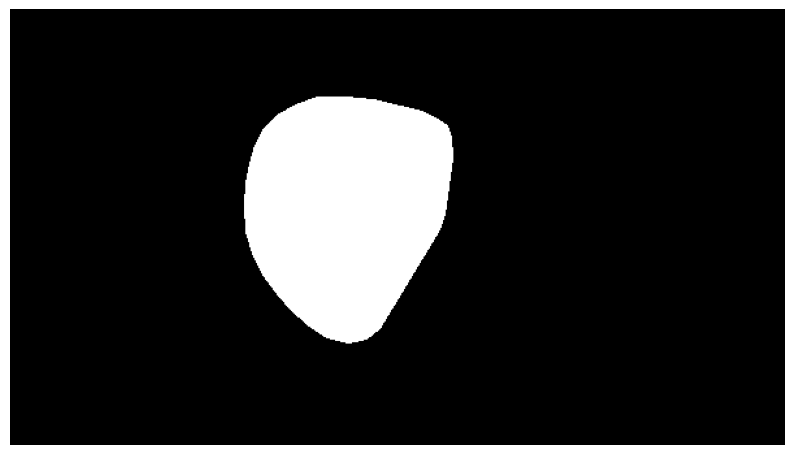

In [88]:
# Empty mask
face_mask = np.zeros(target_img.shape[:2], dtype=np.uint8)

# Fill the convex hull
cv2.fillConvexPoly(
    face_mask,
    hull,
    255
)

# Display mask
plt.figure(figsize=(10, 8))

plt.imshow(
    face_mask,
    cmap="gray"
)

plt.axis("off")
plt.show()

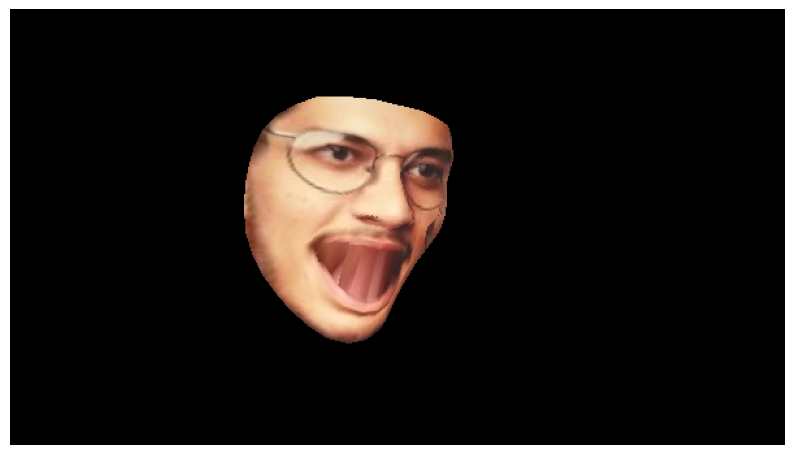

In [89]:
masked_face = cv2.bitwise_and(
    warped_face,
    warped_face,
    mask=face_mask
)

plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(masked_face, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

In [90]:
M = cv2.moments(hull)

center_x = int(M["m10"] / M["m00"])
center_y = int(M["m01"] / M["m00"])

center = (center_x, center_y)

print("Clone center:", center)

Clone center: (257, 152)


In [91]:
result = cv2.seamlessClone(
    masked_face,
    target_img,
    face_mask,
    center,
    cv2.NORMAL_CLONE
)

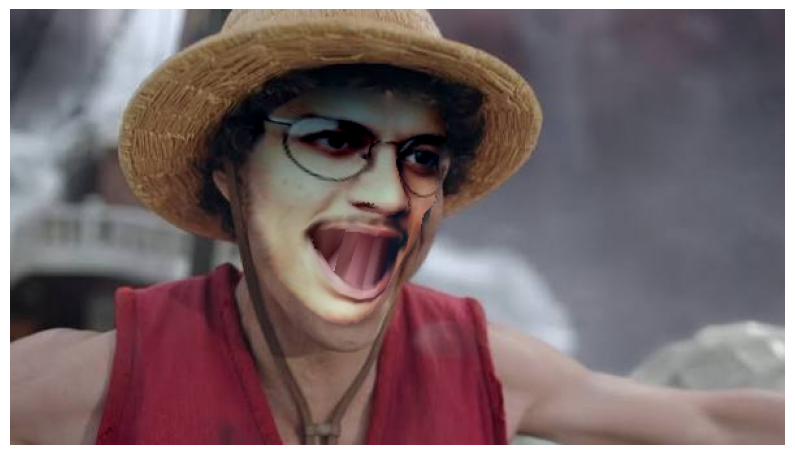

In [92]:
plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

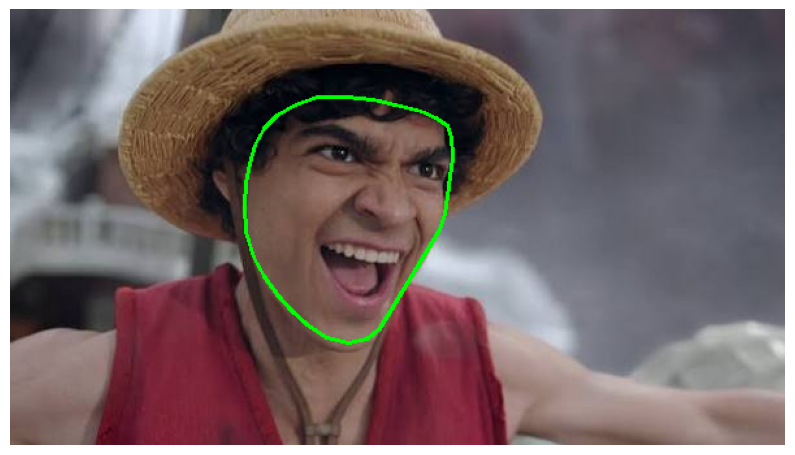

In [93]:
plt.figure(figsize=(10, 8))

debug_mask = target_img.copy()

cv2.polylines(
    debug_mask,
    [hull],
    True,
    (0, 255, 0),
    2
)

plt.imshow(
    cv2.cvtColor(debug_mask, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

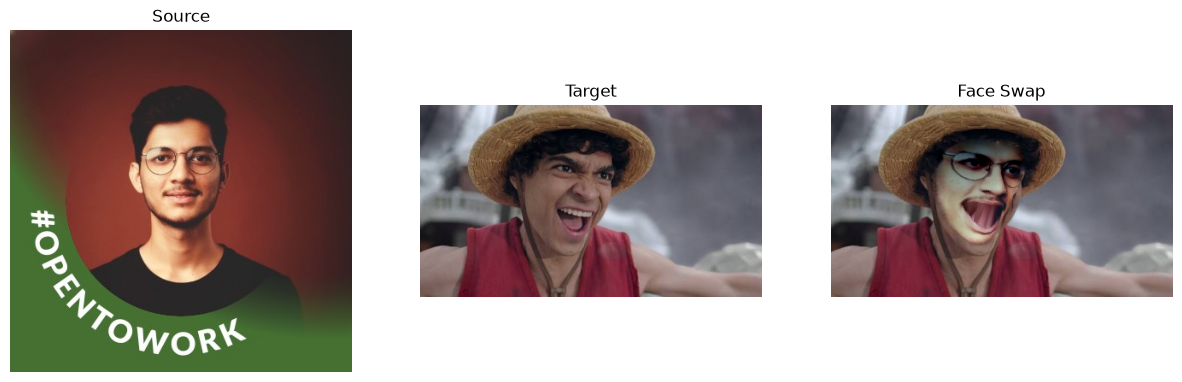

In [94]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB))
plt.title("Source")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
plt.title("Target")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Face Swap")
plt.axis("off")

plt.show()

In [100]:
import cv2
import numpy as np
import mediapipe as mp
from scipy.spatial import Delaunay
import time


# ============================================================
# 1. LOAD SOURCE IMAGE
# ============================================================

source_img = cv2.imread("M.jpg")

if source_img is None:
    raise FileNotFoundError("Could not load profile1.jpeg")

print("Source image:", source_img.shape)


# ============================================================
# 2. MEDIAPIPE FACE LANDMARKER
# ============================================================

MODEL_PATH = "/home/sumanth/Downloads/face_landmarker.task"

BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = mp.tasks.vision.FaceLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=MODEL_PATH
    ),
    running_mode=VisionRunningMode.VIDEO,
    num_faces=1
)

landmarker = mp.tasks.vision.FaceLandmarker.create_from_options(options)


# ============================================================
# 3. GET LANDMARKS FROM SOURCE IMAGE
# ============================================================

source_rgb = cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB)

source_mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=source_rgb
)

source_result = landmarker.detect_for_video(
    source_mp_image,
    0
)

if not source_result.face_landmarks:
    raise RuntimeError("No face detected in source image")

source_landmarks = source_result.face_landmarks[0]

source_points = np.array([
    [
        lm.x * source_img.shape[1],
        lm.y * source_img.shape[0]
    ]
    for lm in source_landmarks
], dtype=np.float32)

print("Source landmarks:", len(source_points))


# ============================================================
# 4. DELAUNAY TRIANGULATION
# ============================================================

# Use first 468 landmarks
# These are the standard face mesh landmarks.
source_points = source_points[:468]

tri = Delaunay(source_points)

print("Triangles:", len(tri.simplices))


# ============================================================
# 5. FUNCTION TO WARP SOURCE FACE
# ============================================================

def warp_face(source_img, source_points, target_points, triangles, target_shape):

    target_h, target_w = target_shape[:2]

    warped_face = np.zeros(
        (target_h, target_w, 3),
        dtype=np.uint8
    )

    for triangle_indices in triangles:

        src_tri = source_points[triangle_indices].astype(np.float32)
        dst_tri = target_points[triangle_indices].astype(np.float32)

        # Bounding rectangles
        sx, sy, sw, sh = cv2.boundingRect(src_tri)
        dx, dy, dw, dh = cv2.boundingRect(dst_tri)

        if sw <= 0 or sh <= 0 or dw <= 0 or dh <= 0:
            continue

        # Make sure rectangles are inside image
        if (
            sx < 0 or sy < 0 or
            sx + sw > source_img.shape[1] or
            sy + sh > source_img.shape[0]
        ):
            continue

        if (
            dx < 0 or dy < 0 or
            dx + dw > target_w or
            dy + dh > target_h
        ):
            continue

        # Shift triangle coordinates
        src_tri_rect = src_tri - np.array(
            [sx, sy],
            dtype=np.float32
        )

        dst_tri_rect = dst_tri - np.array(
            [dx, dy],
            dtype=np.float32
        )

        # Source crop
        src_crop = source_img[
            sy:sy+sh,
            sx:sx+sw
        ]

        # Affine transformation
        matrix = cv2.getAffineTransform(
            src_tri_rect,
            dst_tri_rect
        )

        # Warp
        warped = cv2.warpAffine(
            src_crop,
            matrix,
            (dw, dh),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )

        # Triangle mask
        mask = np.zeros(
            (dh, dw),
            dtype=np.uint8
        )

        cv2.fillConvexPoly(
            mask,
            dst_tri_rect.astype(np.int32),
            255
        )

        # Destination region
        destination = warped_face[
            dy:dy+dh,
            dx:dx+dw
        ]

        # Composite
        destination[mask == 255] = warped[mask == 255]

        warped_face[
            dy:dy+dh,
            dx:dx+dw
        ] = destination

    return warped_face


# ============================================================
# 6. WEBCAM
# ============================================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam")

# Reduce resolution for better FPS
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)


frame_timestamp = 0

print("Webcam started.")
print("Press Q or ESC to quit.")


# ============================================================
# 7. REAL-TIME LOOP
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        print("Failed to read webcam frame")
        break

    # Mirror webcam
    frame = cv2.flip(frame, 1)

    # Convert BGR → RGB
    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # MediaPipe image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # Timestamp must increase
    frame_timestamp += 33

    result = landmarker.detect_for_video(
        mp_image,
        frame_timestamp
    )

    # --------------------------------------------------------
    # If face detected
    # --------------------------------------------------------

    if result.face_landmarks:

        target_landmarks = result.face_landmarks[0]

        target_points = np.array([
            [
                lm.x * frame.shape[1],
                lm.y * frame.shape[0]
            ]
            for lm in target_landmarks
        ], dtype=np.float32)

        # Use first 468 landmarks
        target_points = target_points[:468]

        # ----------------------------------------------------
        # Warp source face
        # ----------------------------------------------------

        warped_face = warp_face(
            source_img,
            source_points,
            target_points,
            tri.simplices,
            frame.shape
        )

        # ----------------------------------------------------
        # Create face mask
        # ----------------------------------------------------

        hull = cv2.convexHull(
            target_points.astype(np.int32)
        )

        face_mask = np.zeros(
            frame.shape[:2],
            dtype=np.uint8
        )

        cv2.fillConvexPoly(
            face_mask,
            hull,
            255
        )

        # Slightly soften mask
        face_mask = cv2.GaussianBlur(
            face_mask,
            (21, 21),
            0
        )

        # ----------------------------------------------------
        # Find center
        # ----------------------------------------------------

        M = cv2.moments(hull)

        if M["m00"] != 0:

            center_x = int(
                M["m10"] / M["m00"]
            )

            center_y = int(
                M["m01"] / M["m00"]
            )

            center = (
                center_x,
                center_y
            )

            # ------------------------------------------------
            # Seamless clone
            # ------------------------------------------------

            try:

                output = cv2.seamlessClone(
                    warped_face,
                    frame,
                    face_mask,
                    center,
                    cv2.NORMAL_CLONE
                )

            except cv2.error:

                output = frame.copy()

        else:

            output = frame.copy()

    else:

        # No face detected
        output = frame.copy()

    # ========================================================
    # DISPLAY
    # ========================================================

    cv2.putText(
        output,
        "Face Swap - Press Q to quit",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    cv2.imshow(
        "Real-Time Face Swap",
        output
    )

    # Quit
    key = cv2.waitKey(1) & 0xFF

    if key == ord("q") or key == 27:
        break


# ============================================================
# CLEANUP
# ============================================================

cap.release()
cv2.destroyAllWindows()

landmarker.close()

print("Webcam stopped.")

Source image: (307, 250, 3)
Source landmarks: 478
Triangles: 898


W0000 00:00:1791373276.367258  553964 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1791373276.395533  553966 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791373276.484704  553966 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Webcam started.
Press Q or ESC to quit.
Webcam stopped.
